# Seasonal Average Hourly Forecast, by Forecaster

Average predicted diurnal profile (`pl_hat`, the copula mean anchor -- the same
quantity used as `bid`'s target and everywhere else in this project, not the raw
median) over the sealed test year, one line per season (spring/summer/autumn/winter,
meteorological definition), one panel per forecaster family. N=5 seed mean +/- std
shaded for the three retrained families; baseline is a single fixed checkpoint (n=1,
no shading).

This is the forecast-side analogue of the earlier ground-truth EDA finding
(`2_eda/prosumption_price_eda.ipynb`) that the *realised* diurnal shape genuinely
shifts with season (winter trough ~04:00, summer trough ~12:00-14:00, solar-driven) --
this notebook checks whether each forecaster's own *predicted* shape tracks that same
shift.

## Setup

In [1]:
from __future__ import annotations
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR, FrozenCopulaSampler,
)

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_BASE_ID = {
    "Baseline": None,
    "Control": "crps_only_retrained",
    "DFL Single-price": "dfl_1stage_single-price",
    "DFL Dual-price": "dfl_1stage_dual-price",
}
FAMILY_ORDER = list(FAMILY_BASE_ID)
SEASON_MONTHS = {"winter": [12, 1, 2], "spring": [3, 4, 5], "summer": [6, 7, 8], "autumn": [9, 10, 11]}
SEASON_ORDER = ["spring", "summer", "autumn", "winter"]
SEASON_COLORS = {"spring": "C2", "summer": "C1", "autumn": "C5", "winter": "C0"}


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


print("loading test windows...")
windows = load_test_windows()
n_days = len(windows.delivery_start)
months = np.array([windows.delivery_start[d].month for d in range(n_days)])
SEASON_DAY_INDICES = {season: np.where(np.isin(months, mo))[0] for season, mo in SEASON_MONTHS.items()}
for season in SEASON_ORDER:
    print(f"  {season:8s}: {len(SEASON_DAY_INDICES[season])} days")

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)


cop = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop["Z_corr"], cop["quantile_levels"])

loading test windows...


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
  spring  : 92 days
  summer  : 92 days
  autumn  : 91 days
  winter  : 91 days


### Collection

For each forecaster, compute `pl_hat` for every test day, then average by hour-of-day
within each season -- one (24,) profile per season per forecaster-seed.

In [2]:
def seasonal_hourly_means(model):
    """dict season -> (24,) mean pl_hat by hour, averaged over that season's test days."""
    pl_hat_all = np.empty((n_days, 24))
    for d in range(n_days):
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        pl_hat_all[d] = mean.detach().cpu().numpy()
    return {season: pl_hat_all[idx].mean(axis=0) for season, idx in SEASON_DAY_INDICES.items()}


RESULTS = {}   # family -> {season: (mean (24,), std (24,) or None)}
for family in FAMILY_ORDER:
    base_id = FAMILY_BASE_ID[family]
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    per_seed = []   # list of dict season -> (24,)
    for seed in seeds:
        model = baseline_model if family == "Baseline" else load_dfl(seed_variant(base_id, seed))
        per_seed.append(seasonal_hourly_means(model))
        print(f"  collected {family} seed={seed}", flush=True)
    RESULTS[family] = {}
    for season in SEASON_ORDER:
        stacked = np.array([ps[season] for ps in per_seed])   # (n_seeds, 24)
        RESULTS[family][season] = (stacked.mean(axis=0), stacked.std(axis=0) if len(seeds) > 1 else None)

  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


  collected Control seed=20240804


...

  collected DFL Dual-price seed=20240801


  collected DFL Dual-price seed=20240802


  collected DFL Dual-price seed=20240803


  collected DFL Dual-price seed=20240804


  collected DFL Dual-price seed=20240805


## Average hourly forecast by season, one panel per forecaster

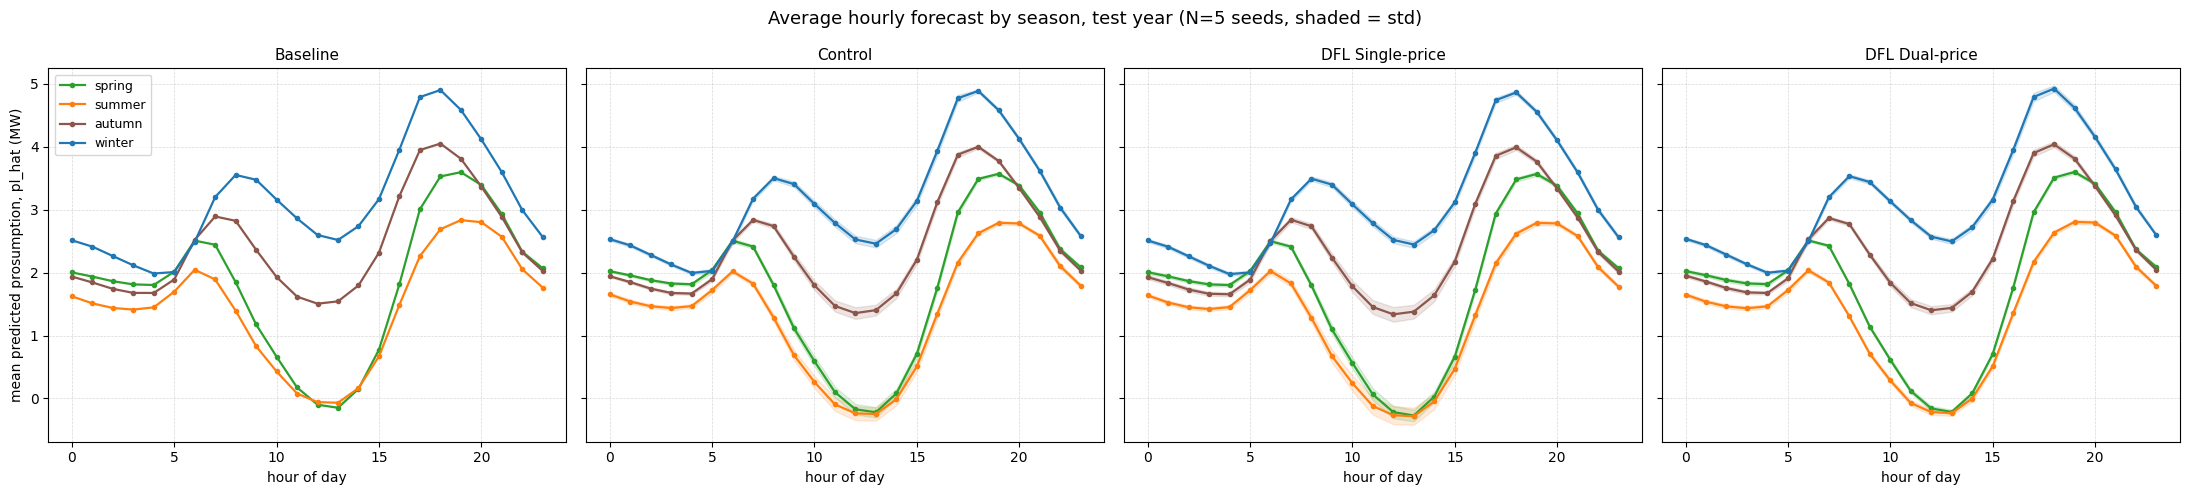

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
h = np.arange(24)
for ax, family in zip(axes, FAMILY_ORDER):
    for season in SEASON_ORDER:
        mean, std = RESULTS[family][season]
        ax.plot(h, mean, "-o", color=SEASON_COLORS[season], markersize=3, label=season, linewidth=1.6)
        if std is not None:
            ax.fill_between(h, mean - std, mean + std, color=SEASON_COLORS[season], alpha=0.15)
    ax.set_title(family, fontsize=11)
    ax.set_xlabel("hour of day")
    ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].set_ylabel("mean predicted prosumption, pl_hat (MW)")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("Average hourly forecast by season, test year (N=5 seeds, shaded = std)", fontsize=13)
fig.tight_layout()
plt.show()